In [4]:
#Step 1 — Import libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria
!unzip -q cell-images-for-detecting-malaria.zip -d cell_images_data

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
100% 675M/675M [00:27<00:00, 26.0MB/s]



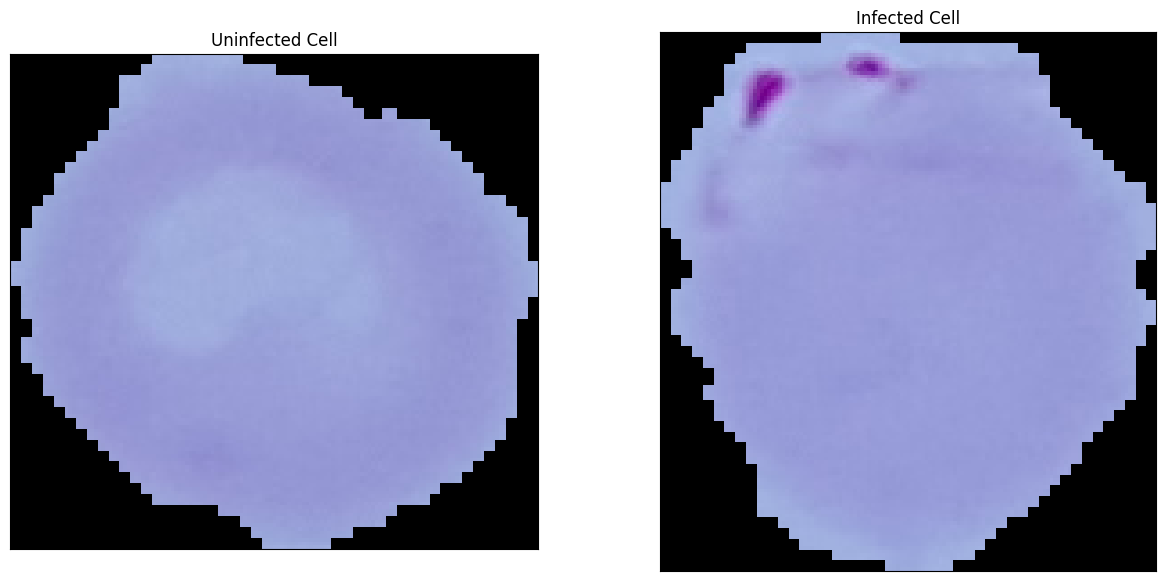

In [6]:
#Step 2 — Look at your data first
upic = 'cell_images_data/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_131.png'
apic = 'cell_images_data/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_164.png'

plt.figure(1, figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.imread(upic))
plt.title('Uninfected Cell')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(cv2.imread(apic))
plt.title('Infected Cell')
plt.xticks([]), plt.yticks([])
plt.show()

In [7]:
#Step 3 — Set image size
width = 128
height = 128

In [10]:
datagen = ImageDataGenerator(rescale=1/255.0, validation_split=0.2)

trainDatagen = datagen.flow_from_directory(
    directory='cell_images_data/cell_images/cell_images/',
    target_size=(width, height),
    class_mode='binary',
    batch_size=16,
    subset='training'
)

valDatagen = datagen.flow_from_directory (
   directory='cell_images_data/cell_images/cell_images/',
   target_size=(width, height),
   class_mode='binary',
   batch_size=16,
   subset='validation'
    )

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [11]:
#Step 5 — Build the CNN (Convolutional Neural Network)
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(width, height, 3)))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Step 5 — Build the CNN (Convolutional Neural Network)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
#Step 7 — Train the model (this is the big improvement over your original)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    trainDatagen,
    steps_per_epoch=len(trainDatagen),
    epochs=20,
    validation_data=valDatagen,
    validation_steps=len(valDatagen),
    callbacks=[early_stop]
)

Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 272s 196ms/step - accuracy: 0.7589 - loss: 0.4773 - val_accuracy: 0.9354 - val_loss: 0.1956
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 294s 176ms/step - accuracy: 0.9472 - loss: 0.1750 - val_accuracy: 0.9441 - val_loss: 0.1708
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 272s 183ms/step - accuracy: 0.9519 - loss: 0.1596 - val_accuracy: 0.9417 - val_loss: 0.1812
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 258s 187ms/step - accuracy: 0.9545 - loss: 0.1512 - val_accuracy: 0.9428 - val_loss: 0.1616
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 239s 171ms/step - accuracy: 0.9553 - loss: 0.1443 - val_accuracy: 0.9446 - val_loss: 0.1646
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 265s 173ms/step - accuracy: 0.9574 - loss: 0.1380 - val_accuracy: 0.9278 - val_loss: 0.2035
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 236s 172ms/step - accuracy: 0.9574 - loss: 0.1329 - val_accuracy: 0.9461 - val_loss: 0.1621


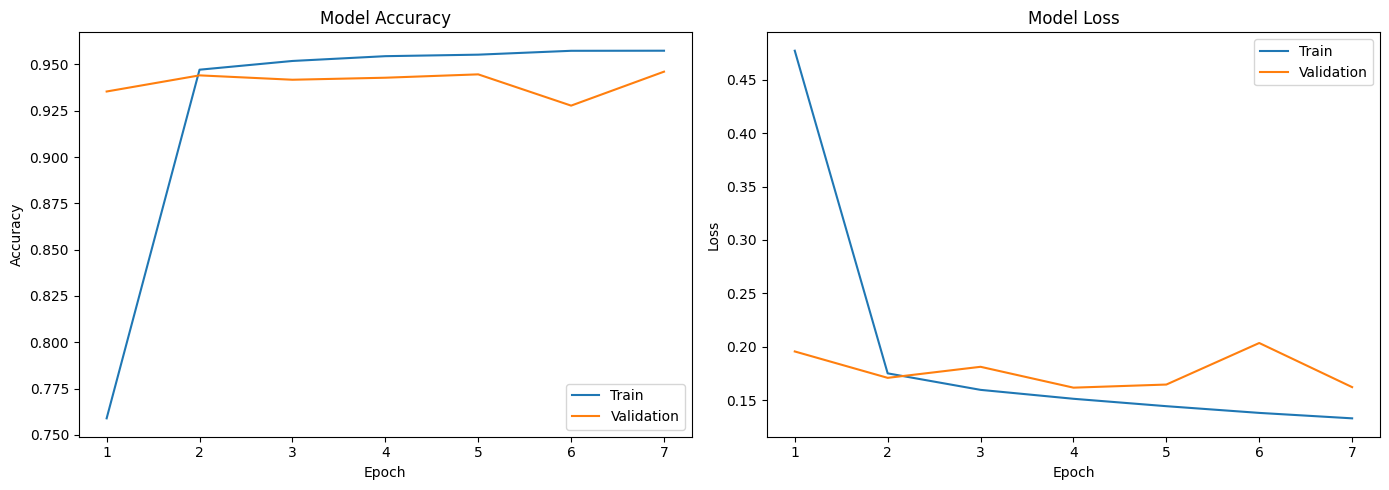

In [14]:
#Step 8 — Plot learning curves
def plotLearningCurve(history):
    epochs_ran = len(history.history['accuracy'])
    epochRange = range(1, epochs_ran + 1)

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(epochRange, history.history['accuracy'], label='Train')
    plt.plot(epochRange, history.history['val_accuracy'], label='Validation')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochRange, history.history['loss'], label='Train')
    plt.plot(epochRange, history.history['val_loss'], label='Validation')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotLearningCurve(history)



345/345 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step
Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.50      0.47      0.48      2755
  Uninfected       0.50      0.53      0.51      2755

    accuracy                           0.50      5510
   macro avg       0.50      0.50      0.50      5510
weighted avg       0.50      0.50      0.50      5510



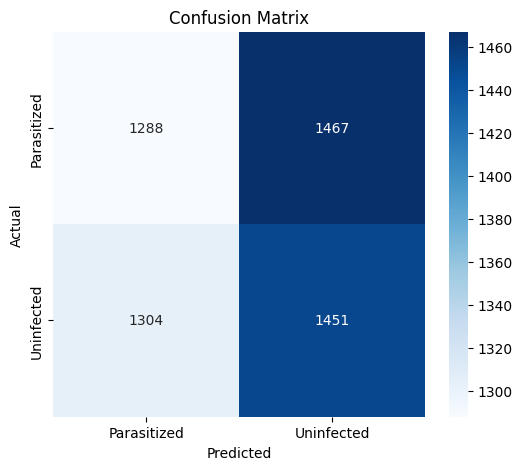

In [15]:
#Step 9 — Real evaluation (this was completely missing before)
valDatagen.reset()
y_true = valDatagen.classes
y_pred_probs = model.predict(valDatagen, steps=len(valDatagen))
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

class_labels = list(valDatagen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
#Step 10 — Save the model (this makes it usable)
model.save('malaria_cnn_model.h5')
print("Model saved as malaria_cnn_model.h5")

Model saved as malaria_cnn_model.h5


In [17]:
#Step 11 — Test it works end to end
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

loaded_model = load_model('malaria_cnn_model.h5')

test_img_path = apic
img = image.load_img(test_img_path, target_size=(width, height))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = loaded_model.predict(img_array)[0][0]
label = class_labels[int(prediction > 0.5)]
confidence = prediction if prediction > 0.5 else 1 - prediction

print(f"Predicted class: {label}")
print(f"Confidence: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted class: Parasitized
Confidence: 100.00%


In [18]:
# create a separate generator just for evaluation, with shuffle turned off
eval_datagen = datagen.flow_from_directory(
    directory='cell_images_data/cell_images/cell_images/',
    target_size=(width, height),
    class_mode='binary',
    batch_size=16,
    subset='validation',
    shuffle=False  # this is the critical fix
)

y_true = eval_datagen.classes
y_pred_probs = model.predict(eval_datagen, steps=len(eval_datagen))
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

class_labels = list(eval_datagen.class_indices.keys())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

Found 5510 images belonging to 2 classes.
345/345 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step
Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.97      0.91      0.94      2755
  Uninfected       0.92      0.97      0.94      2755

    accuracy                           0.94      5510
   macro avg       0.94      0.94      0.94      5510
weighted avg       0.94      0.94      0.94      5510

